
🌳 Extra Trees Model Results:
MAE: 8.82, MAPE: 21.04%, RMSE: 17.24, R²: 0.986


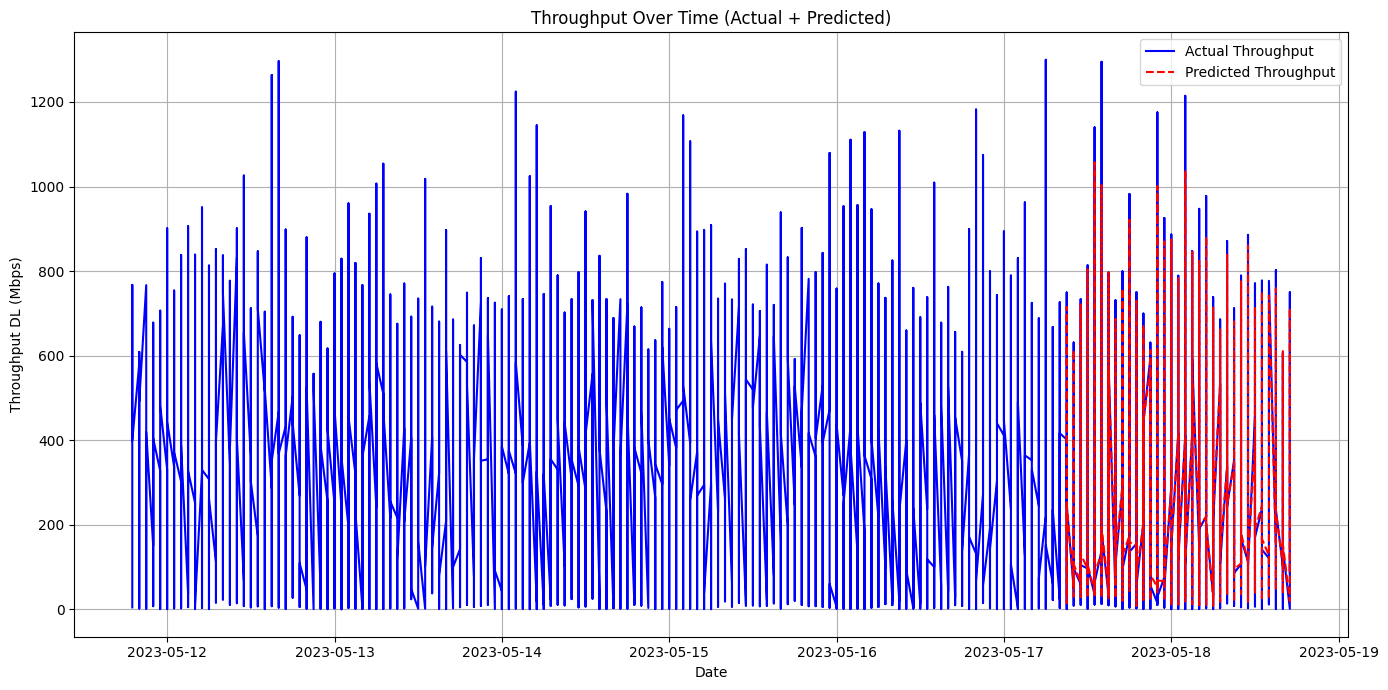

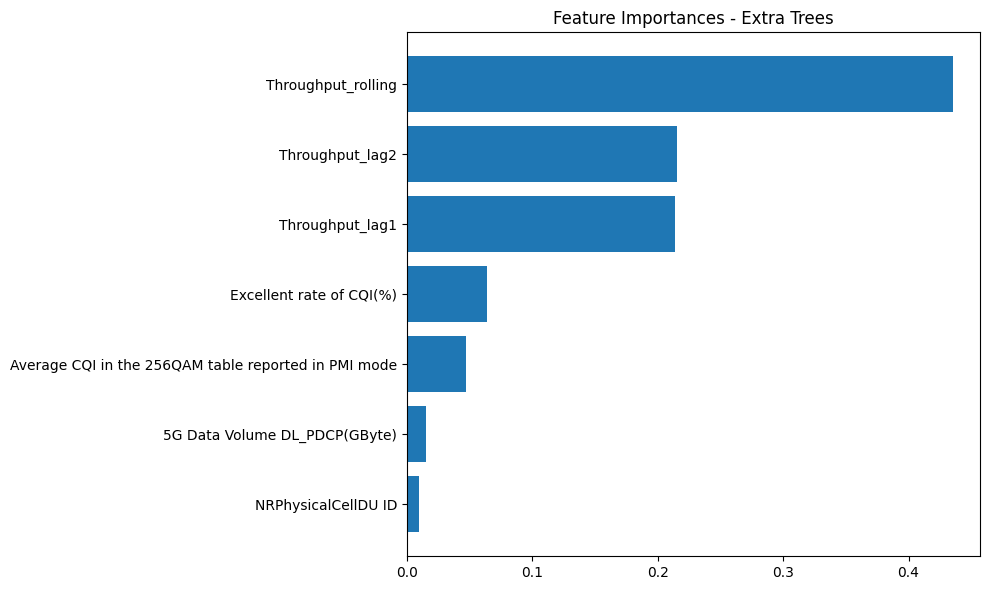

['scaler.pkl']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================
# 1. Load and Preprocess Data
# =====================

df = pd.read_excel("/Users/morrisonosiezagha/Downloads/5G_OSSKPI_dataset.xlsx")
df["Begin Time"] = pd.to_datetime(df["Begin Time"])
df = df.sort_values("Begin Time").reset_index(drop=True)

# =====================
# 2. Feature Engineering
# =====================

df["Throughput"] = df["NR RAN UE Throughput DL(Mbps)"].astype(str).str.replace(",", "", regex=False).astype(float)
df["Throughput_rolling"] = df["Throughput"].rolling(3).mean()
df["Throughput_lag1"] = df["Throughput"].shift(1)
df["Throughput_lag2"] = df["Throughput"].shift(2)
df["hour"] = df["Begin Time"].dt.hour
df["dayofweek"] = df["Begin Time"].dt.dayofweek

features = [
    "Throughput",  # Target
    "Throughput_rolling",
    "Throughput_lag1",
    "Throughput_lag2",
    # "5G Cell Availability",
    "Average CQI in the 256QAM table reported in PMI mode",
    "5G Data Volume DL_PDCP(GByte)",
    "Excellent rate of CQI(%)",
    # "Number of times that an SN is added successfully",
    "NRPhysicalCellDU ID",
    # "Average delay of DL RLC SDU packets of NSA UEs in a cell(ms)",
    # "Average UL interference level in a cell(dBm)"
]

# Clean and convert all relevant features
for col in features[1:]:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False).replace("-", np.nan).astype(float)

df = df.dropna(subset=features)

# =====================
# 3. Define X, y and Scale
# =====================

X = df[features[1:]]  # All predictors
y = df["Throughput"]  # Target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# =====================
# 4. Train-Test Split
# =====================

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# =====================
# 5. Train Extra Trees Regressor
# =====================

et = ExtraTreesRegressor(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

# =====================
# 6. Predict and Evaluate
# =====================

y_pred = et.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n🌳 Extra Trees Model Results:\nMAE: {mae:.2f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}, R²: {r2:.3f}")

# =====================
# 7. Plot Full Throughput with Prediction
# =====================

# Dates for the full data
all_dates = df["Begin Time"].iloc[-len(y):]
train_dates = all_dates[:len(y_train)]
test_dates = all_dates[len(y_train):]

# Full actual throughput values
full_actual = y.values

# Full predicted: keep training part as NaN, predicted part as values
full_predicted = np.empty_like(full_actual)
full_predicted[:] = np.nan
full_predicted[-len(y_test):] = y_pred

plt.figure(figsize=(14, 7))
plt.plot(all_dates, full_actual, label="Actual Throughput", color="blue")
plt.plot(all_dates, full_predicted, label="Predicted Throughput", color="Red", linestyle="--")

plt.title("Throughput Over Time (Actual + Predicted)")
plt.xlabel("Date")
plt.ylabel("Throughput DL (Mbps)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =====================
# 8. Feature Importance Plot
# =====================

importances = et.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[sorted_idx], align="center")
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_idx])
plt.gca().invert_yaxis()
plt.title("Feature Importances - Extra Trees")
plt.tight_layout()
plt.show()

import joblib

joblib.dump(et, "extra_trees_model.pkl")
joblib.dump(scaler, "scaler.pkl")


In [2]:
%%writefile app.py
import streamlit as st

# Load model and scaler
model = joblib.load("extra_trees_model.pkl")
scaler = joblib.load("scaler.pkl")

# Page config
st.set_page_config(page_title="5G Throughput Predictor", layout="wide")

# Title
st.title("📡 5G Throughput Predictor Dashboard")
st.markdown("Predict downlink throughput using key 5G NR radio features.")

# Sidebar inputs
st.sidebar.header("📥 Input 5G Parameters")

data_volume = st.sidebar.number_input("DL Data Volume (MB)", min_value=0.0, value=4172.0)

avg_cqi = st.sidebar.number_input("Average CQI (256QAM)", min_value=0.0, max_value=15.0, value=11.3)

excellent_cqi_rate = st.sidebar.slider("Excellent CQI Rate (%)", min_value=0.0, max_value=100.0, value=98.0)

cell_id = st.sidebar.number_input("NR Cell ID", min_value=0, value=101)

# Combine inputs into array
input_data = np.array([[data_volume, avg_cqi, excellent_cqi_rate, cell_id]])

# Scale input
input_scaled = scaler.transform(input_data)

# Prediction
if st.sidebar.button("🔍 Predict Throughput"):
    prediction = model.predict(input_scaled)

    st.subheader("📊 Prediction Result")
    st.success(f"Estimated Throughput: {prediction[0]:.2f} Mbps")

    # Additional insight
    if prediction[0] < 10:
        st.warning("⚠️ Low throughput detected. Possible poor radio conditions.")
    elif prediction[0] < 50:
        st.info("ℹ️ متوسط performance. Optimization may improve throughput.")
    else:
        st.success("✅ Good network performance detected.")


Writing app.py
